# 12. Model Development

This notebook develops, evaluates, and compares machine learning models for the Store Sales Forecasting problem using the engineered features created in the previous notebook.

The modeling process follows an iterative approach, beginning with a baseline LightGBM model and progressively improving performance through feature engineering, target transformation, and hyperparameter tuning. Models are evaluated using a time-based validation strategy to simulate real-world forecasting.

The final trained model will be used in the next notebook to perform recursive forecasting and generate the competition submission.

## Objective

The objectives of this notebook are to:

1. Load the engineered feature matrix.
2. Prepare chronological training and validation datasets.
3. Train a baseline LightGBM model.
4. Evaluate forecasting performance using multiple metrics.
5. Improve the model through feature and parameter refinements.
6. Compare model performance across iterations.
7. Train the final model for recursive forecasting.

## Workflow

The modeling process consists of:

1. Loading the engineered feature matrix.
2. Preparing training and validation datasets.
3. Training the baseline LightGBM model.
4. Evaluating model performance.
5. Improving the model through iterative refinements.
6. Comparing model performance.
7. Training the final production model.
8. Passing the trained model to the recursive forecasting pipeline.

In [1]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
from pathlib import Path
# Visualization
import matplotlib.pyplot as plt

# Model
import lightgbm as lgb
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [2]:
PROCESSED_DATA = Path("../data/processed")

MODEL_DIR = Path("../outputs/models")
MODEL_DIR.mkdir(parents=True, exist_ok=True)

train = pd.read_csv(PROCESSED_DATA / "train.csv", parse_dates=["date"])
oil = pd.read_csv(PROCESSED_DATA / "oil.csv", parse_dates=["date"])
transactions = pd.read_csv(PROCESSED_DATA / "transactions.csv", parse_dates=["date"])

stores = pd.read_csv("../data/raw/stores.csv")
holidays = pd.read_csv("../data/raw/holidays_events.csv", parse_dates=["date"])
test = pd.read_csv("../data/raw/test.csv", parse_dates=["date"])
train_fe = pd.read_csv(
    PROCESSED_DATA / "train_fe.csv",
    parse_dates=["date"]
)

test_fe = pd.read_csv(
    PROCESSED_DATA / "test_fe.csv",
    parse_dates=["date"]
)

# 13. Prepare Training Data

The engineered feature matrix is divided into training and validation sets using a time-based split.

Unlike random train-test splitting, chronological splitting preserves the temporal ordering of observations and provides a realistic estimate of forecasting performance on future data.

Categorical variables are converted to the appropriate data type before model training.

In [3]:
FEATURES = [
    # calendar features
    "day_of_week", "month", "is_weekend",
    # lags
    "lag_1", "lag_7", "lag_14", "lag_28",
    # rolling means
    "rolling_mean_7", "rolling_mean_14", "rolling_mean_28",
    # external
    "dcoilwtico", "onpromotion", "transactions_lag_16",
    # holidays
    "is_holiday_national", "day_before_holiday",
    "is_black_friday", "is_cyber_monday", "is_terremoto",
    # store
    "store_nbr", "store_type", "cluster",
    # product category
    "family",
]

TARGET = "sales"
CAT_FEATURES = ["store_nbr", "store_type", "cluster", "family", "day_of_week", "month"]
SPLIT_DATE = "2017-07-31"

X_train = train_fe[train_fe["date"] < SPLIT_DATE][FEATURES].copy()
y_train = train_fe[train_fe["date"] < SPLIT_DATE][TARGET]

X_val = train_fe[train_fe["date"] >= SPLIT_DATE][FEATURES].copy()
y_val = train_fe[train_fe["date"] >= SPLIT_DATE][TARGET]

# Convert categorical features to category type for LightGBM
for col in CAT_FEATURES:
    X_train[col] = X_train[col].astype("category")
    X_val[col]   = X_val[col].astype("category")

print(f"Train: {X_train.shape}, Val: {X_val.shape}")
print(f"Val period: {train_fe[train_fe['date'] >= SPLIT_DATE]['date'].min().date()} "
      f"— {train_fe[train_fe['date'] >= SPLIT_DATE]['date'].max().date()}")


Train: (2979504, 22), Val: (28512, 22)
Val period: 2017-07-31 — 2017-08-15


# 13.1  LightGBM Model

A baseline LightGBM regressor is trained using the initial feature set.

LightGBM is a gradient boosting framework designed for fast and efficient learning on structured tabular data. Early stopping is employed to prevent overfitting by monitoring validation performance during training.

In [4]:
# Train LightGBM
model = lgb.LGBMRegressor(
    n_estimators=1000,
    learning_rate=0.05,
    num_leaves=64,
    min_child_samples=20,
    random_state=42,
    n_jobs=-1,
    verbose=-1
)

model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    callbacks=[
        lgb.early_stopping(stopping_rounds=50, verbose=True),
        lgb.log_evaluation(period=100)
    ]
)

/Users/navdeeshwar/PycharmProjects/Store-Sales-Forecasting/.venv/lib/python3.14/site-packages/lightgbm/sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


Training until validation scores don't improve for 50 rounds
[100]	valid_0's l2: 52205
[200]	valid_0's l2: 50274.4
[300]	valid_0's l2: 50059.1
Early stopping, best iteration is:
[255]	valid_0's l2: 49901.9


,num_leaves,64
,learning_rate,0.05
,n_estimators,1000
,random_state,42
,n_jobs,-1
,verbose,-1
,boosting_type,'gbdt'
,max_depth,-1
,subsample_for_bin,200000
,objective,None
,class_weight,None


# 13.2 Baseline Model Evaluation

The baseline model is evaluated using multiple forecasting metrics:

- Mean Absolute Error (MAE)
- Root Mean Squared Error (RMSE)
- Root Mean Squared Logarithmic Error (RMSLE)

Daily forecast plots and feature importance analysis provide additional insight into the model's predictive behavior.

In [5]:
# Make predictions and calculate metrics
y_pred = model.predict(X_val).clip(0)  # sales cannot be negative

mae   = mean_absolute_error(y_val, y_pred)
rmse  = np.sqrt(mean_squared_error(y_val, y_pred))
rmsle = np.sqrt(mean_squared_error(np.log1p(y_val), np.log1p(y_pred)))

print(f"MAE:   {mae:.4f}")
print(f"RMSE:  {rmse:.4f}")
print(f"RMSLE: {rmsle:.4f}  - Kaggle metric")


MAE:   67.1700
RMSE:  223.3874
RMSLE: 0.5119  - Kaggle metric


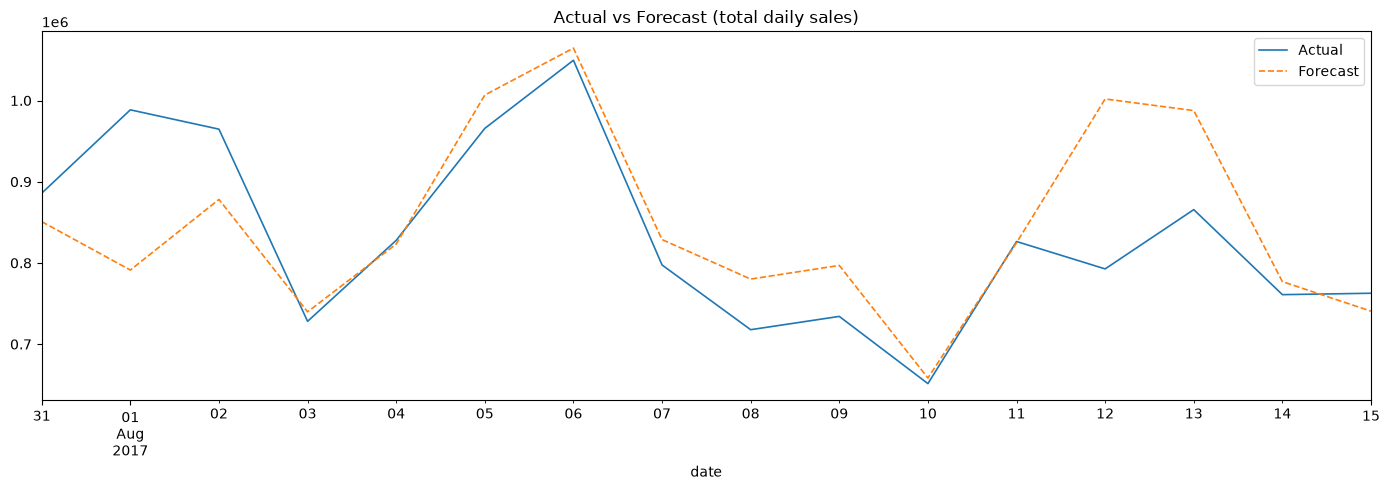

In [6]:
# Sum sales by day for the chart
val_df = train_fe[train_fe["date"] >= SPLIT_DATE][["date"]].copy()
val_df["actual"]    = y_val.values
val_df["predicted"] = y_pred

daily = val_df.groupby("date")[["actual", "predicted"]].sum()

plt.figure(figsize=(14, 5))
daily["actual"].plot(label="Actual", linewidth=1.2)
daily["predicted"].plot(label="Forecast", linewidth=1.2, linestyle="--")
plt.title("Actual vs Forecast (total daily sales)")
plt.legend()
plt.tight_layout()
plt.show()


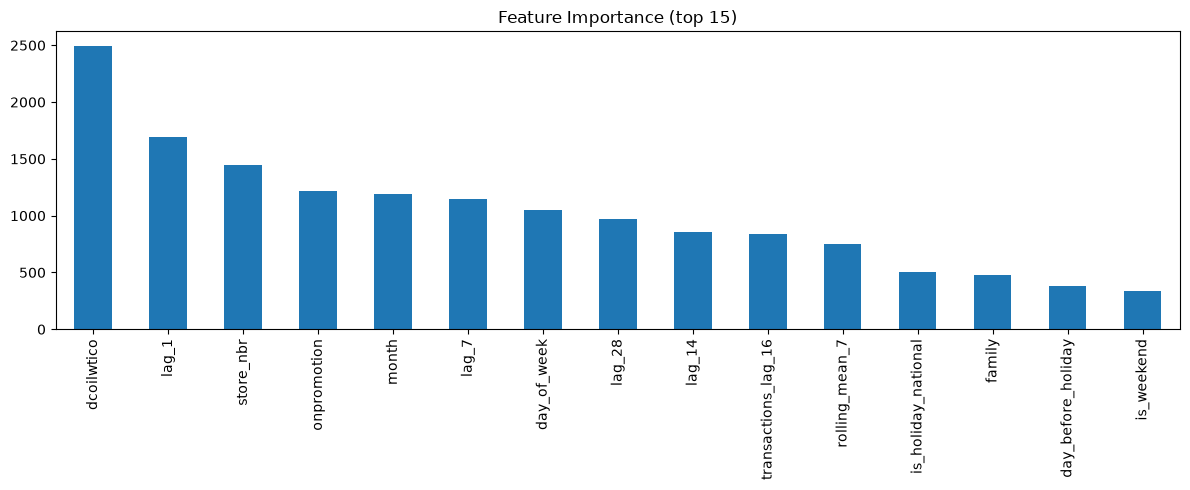

In [7]:
# Look at feature importance
feat_imp = pd.Series(
    model.feature_importances_,
    index=FEATURES
).sort_values(ascending=False)

feat_imp.head(15).plot(kind="bar", figsize=(12, 5), title="Feature Importance (top 15)")
plt.tight_layout()
plt.show()


# 13.3 Improved LightGBM Model

The initial model is further refined by incorporating additional feature engineering improvements, applying a logarithmic transformation to the target variable, and tuning the LightGBM hyperparameters.

These refinements aim to improve generalization performance while preserving the chronological validation strategy established earlier.

In [9]:
FEATURES_V2 = [
    # calendar features
    "day_of_week", "month", "year", "is_weekend",
    "day_of_year", "week_of_year", "date_index",
    # Fourier seasonality features
    "sin_day", "cos_day", "sin_week", "cos_week",
    # lags: short-term 1-6, weekly/monthly, 6-8 weeks, annual
    "lag_1", "lag_2", "lag_3", "lag_4", "lag_5", "lag_6",
    "lag_7", "lag_14", "lag_21", "lag_28", "lag_42", "lag_56",
    "lag_364", "lag_365",
    # rolling means
    "rolling_mean_7", "rolling_mean_14", "rolling_mean_28", "rolling_mean_364",
    # oil and its moving averages
    "dcoilwtico", "dcoilwtico_ma7", "dcoilwtico_ma28",
    # promo and its moving averages
    "onpromotion", "onpromotion_ma7", "onpromotion_ma28",
    # transactions: lags 16-23 days, no leakage from test
    *[f"transactions_lag_{l}" for l in range(16, 24)],
    # holidays
    "is_holiday_national", "day_before_holiday",
    "is_black_friday", "is_cyber_monday", "is_terremoto",
    "is_navidad", "is_dia_madre", "is_futbol",
    "is_dia_trabajo", "is_primer_dia", "is_dia_difuntos", "work_day",
    # store
    "store_nbr", "store_type", "cluster",
    # product category
    "family",
]

X_train2 = train_fe[train_fe["date"] < SPLIT_DATE][FEATURES_V2].copy()
X_val2   = train_fe[train_fe["date"] >= SPLIT_DATE][FEATURES_V2].copy()

y_train2 = np.log1p(y_train)
y_val2   = np.log1p(y_val)

for col in CAT_FEATURES:
    X_train2[col] = X_train2[col].astype("category")
    X_val2[col]   = X_val2[col].astype("category")


In [10]:
# Train improved model with new features and log1p target
model_v2 = lgb.LGBMRegressor(
    n_estimators=10000,
    learning_rate=0.01,
    num_leaves=128,
    min_child_samples=20,
    colsample_bytree=0.8,
    subsample=0.8,
    subsample_freq=1,
    random_state=42,
    n_jobs=-1,
    verbose=-1
)

model_v2.fit(
    X_train2, y_train2,
    eval_set=[(X_val2, y_val2)],
    callbacks=[
        lgb.early_stopping(stopping_rounds=100, verbose=True),
        lgb.log_evaluation(period=200)
    ]
)


/Users/navdeeshwar/PycharmProjects/Store-Sales-Forecasting/.venv/lib/python3.14/site-packages/lightgbm/sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


Training until validation scores don't improve for 100 rounds
[200]	valid_0's l2: 0.274725
[400]	valid_0's l2: 0.154201
[600]	valid_0's l2: 0.148704
[800]	valid_0's l2: 0.145611
[1000]	valid_0's l2: 0.143694
[1200]	valid_0's l2: 0.142188
[1400]	valid_0's l2: 0.141153
[1600]	valid_0's l2: 0.140478
[1800]	valid_0's l2: 0.139892
[2000]	valid_0's l2: 0.139412
[2200]	valid_0's l2: 0.139068
[2400]	valid_0's l2: 0.138757
[2600]	valid_0's l2: 0.138439
[2800]	valid_0's l2: 0.138189
[3000]	valid_0's l2: 0.137927
[3200]	valid_0's l2: 0.137782
[3400]	valid_0's l2: 0.137657
[3600]	valid_0's l2: 0.137544
[3800]	valid_0's l2: 0.137398
[4000]	valid_0's l2: 0.137311
[4200]	valid_0's l2: 0.137192
[4400]	valid_0's l2: 0.137135
[4600]	valid_0's l2: 0.137031
[4800]	valid_0's l2: 0.136976
[5000]	valid_0's l2: 0.136921
[5200]	valid_0's l2: 0.136883
[5400]	valid_0's l2: 0.136873
Early stopping, best iteration is:
[5308]	valid_0's l2: 0.136852


,num_leaves,128
,learning_rate,0.01
,n_estimators,10000
,subsample,0.8
,subsample_freq,1
,colsample_bytree,0.8
,random_state,42
,n_jobs,-1
,verbose,-1
,boosting_type,'gbdt'
,max_depth,-1


# 13.4 Improved Model Evaluation

The improved LightGBM model is evaluated using the same chronological validation strategy as the initial model.

Forecasting performance is compared using multiple evaluation metrics, and daily prediction plots are used to visually assess how well the model captures overall sales trends.

In [11]:
# Calculate prediction and metrics for model_v2
y_pred2 = np.expm1(model_v2.predict(X_val2)).clip(0)

mae2   = mean_absolute_error(y_val, y_pred2)
rmse2  = np.sqrt(mean_squared_error(y_val, y_pred2))
rmsle2 = np.sqrt(mean_squared_error(np.log1p(y_val), np.log1p(y_pred2)))

print(f"MAE:   {mae2:.4f}")
print(f"RMSE:  {rmse2:.4f}")
print(f"RMSLE: {rmsle2:.4f}  - Kaggle metric")


MAE:   58.7657
RMSE:  200.2806
RMSLE: 0.3699  - Kaggle metric


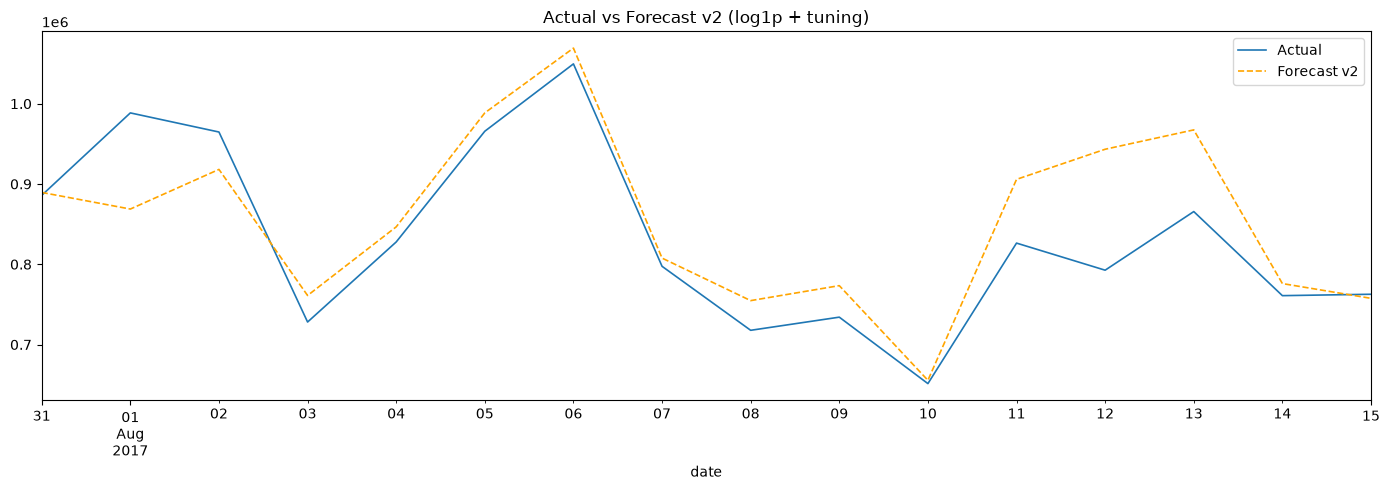

In [12]:
# Compare actual vs model_v2 forecast by day
val_df2 = train_fe[train_fe["date"] >= SPLIT_DATE][["date"]].copy()
val_df2["actual"]    = y_val.values
val_df2["predicted"] = y_pred2

daily2 = val_df2.groupby("date")[["actual", "predicted"]].sum()

plt.figure(figsize=(14, 5))
daily2["actual"].plot(label="Actual", linewidth=1.2)
daily2["predicted"].plot(label="Forecast v2", linewidth=1.2, linestyle="--", color="orange")
plt.title("Actual vs Forecast v2 (log1p + tuning)")
plt.legend()
plt.tight_layout()
plt.show()
